# LSTM Price Prediction Testing
Testing LSTM model on S&P 500 daily data

**Workflow:**
1. Load 2023-2024 data for training (inclusive)
2. Train LSTM model once
3. Test on each month of 2025
4. Visualize predictions vs actual prices 
(we are running so every day gets a new prediction, and have overlapping lines and then assesing their accuracy)

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import your modules
from Data_Handling import get_data_auto
from LSTM_Price_Predictor import LSTMPricePredictor

## 1. Configuration & Data Loading

In [2]:
# Experiment parameters
SYMBOL = "SPY"  # S&P 500 ETF
TIMEFRAME_UNIT = "Day"
MULTIPLIER = 1

# Training period
TRAIN_START = "2023-01-01"
TRAIN_END = "2024-12-31"

# Testing period
TEST_START = "2025-01-01"
TEST_END = "2025-12-31"

# Model parameters
LOOKBACK_WINDOW = 100
PREDICTION_HORIZON = 5
LSTM_UNITS = 50
NUM_LAYERS = 2
DROPOUT = 0.2
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001
PREDICTION_MODE = 'recursive'  # or 'direct'

# Model persistence
MODEL_NAME = f"lstm_{SYMBOL}_{TRAIN_START}_{TRAIN_END}"
RETRAIN = False  # Set to True to force retraining

In [3]:
# Load training data
print(f"Loading training data: {TRAIN_START} to {TRAIN_END}")
train_data = get_data_auto(SYMBOL, start=TRAIN_START, end=TRAIN_END, 
                           timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"\nTraining data shape: {train_data.shape}")
print(f"Date range: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Number of trading days: {len(train_data)}")
train_data.head()

Loading training data: 2023-01-01 to 2024-12-31

Training data shape: (501, 5)
Date range: 2023-01-03 05:00:00+00:00 to 2024-12-30 05:00:00+00:00
Number of trading days: 501

Training data shape: (501, 5)
Date range: 2023-01-03 05:00:00+00:00 to 2024-12-30 05:00:00+00:00
Number of trading days: 501


field,Open,High,Low,Close,Volume
timestamp,,,,,
2023-01-03 05:00:00+00:00,369.481572,371.461777,363.194888,366.069092,74850700.0
2023-01-04 05:00:00+00:00,368.337622,370.933050,365.280805,368.895172,85934100.0
2023-01-05 05:00:00+00:00,366.934233,367.049580,364.088896,364.684875,76970500.0
2023-01-06 05:00:00+00:00,367.789789,374.172606,364.713757,373.047913,104189600.0
2023-01-09 05:00:00+00:00,375.249150,378.450180,372.653751,372.836365,73978100.0


In [4]:
# Load testing data
print(f"Loading testing data: {TEST_START} to {TEST_END}")
test_data = get_data_auto(SYMBOL, start=TEST_START, end=TEST_END,
                          timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"\nTesting data shape: {test_data.shape}")
print(f"Date range: {test_data.index[0]} to {test_data.index[-1]}")
print(f"Number of trading days: {len(test_data)}")
test_data.head()

Loading testing data: 2025-01-01 to 2025-12-31

Testing data shape: (249, 5)
Date range: 2025-01-02 05:00:00+00:00 to 2025-12-30 05:00:00+00:00
Number of trading days: 249


field,Open,High,Low,Close,Volume
timestamp,,,,,
2025-01-02 05:00:00+00:00,582.549116,584.268911,573.762285,577.854248,50204000.0
2025-01-03 05:00:00+00:00,580.710665,585.721765,579.623396,585.079346,37888500.0
2025-01-06 05:00:00+00:00,589.349240,592.739421,586.710186,588.449768,47679400.0
2025-01-07 05:00:00+00:00,590.485867,590.812054,579.969409,581.797913,60393100.0
2025-01-08 05:00:00+00:00,581.867018,583.725202,578.407643,582.647827,47304700.0


## 2. Model Training (or Loading)

In [5]:
# Initialize model
predictor = LSTMPricePredictor(
    lookback_window=LOOKBACK_WINDOW,
    prediction_horizon=PREDICTION_HORIZON,
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    prediction_mode=PREDICTION_MODE,
    verbose=1
)

print(f"Model configuration:")
print(f"  Lookback window: {LOOKBACK_WINDOW} candles")
print(f"  Prediction horizon: {PREDICTION_HORIZON} candles")
print(f"  LSTM units: {LSTM_UNITS}")
print(f"  Layers: {NUM_LAYERS}")
print(f"  Prediction mode: {PREDICTION_MODE}")

Model configuration:
  Lookback window: 100 candles
  Prediction horizon: 5 candles
  LSTM units: 50
  Layers: 2
  Prediction mode: recursive


In [6]:
# Train or load model
import os

model_path = os.path.join('models', f"{MODEL_NAME}.keras")

if os.path.exists(model_path) and not RETRAIN:
    print(f"\n{'='*60}")
    print("Loading existing model...")
    print(f"{'='*60}")
    predictor.load_model(MODEL_NAME)
else:
    print(f"\n{'='*60}")
    print("Training new model...")
    print(f"{'='*60}")
    predictor.fit(train_data, validation_split=0.2, early_stopping_patience=10)
    
    # Save the trained model
    print(f"\nSaving model as '{MODEL_NAME}'...")
    predictor.save_model(MODEL_NAME)

print("\nModel ready for predictions!")


Loading existing model...
Model loaded from models\lstm_SPY_2023-01-01_2024-12-31.keras
Trained on: 2026-01-20 00:01:22
Training loss: 0.857682

Model ready for predictions!
Model loaded from models\lstm_SPY_2023-01-01_2024-12-31.keras
Trained on: 2026-01-20 00:01:22
Training loss: 0.857682

Model ready for predictions!


## 3. View Training History

In [7]:
# Plot training history (if we just trained)
if predictor.training_history is not None:
    history_df = predictor.get_training_history()
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    ax1 = axes[0]
    ax1.plot(history_df['epoch'], history_df['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_title('Training History: Loss')
    ax1.legend()
    ax1.grid(True)
    
    # MAE
    ax2 = axes[1]
    ax2.plot(history_df['epoch'], history_df['mae'], label='Training MAE', linewidth=2)
    ax2.plot(history_df['epoch'], history_df['val_mae'], label='Validation MAE', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.set_title('Training History: MAE')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Model was loaded from disk, no training history available.")

Model was loaded from disk, no training history available.


## 4. Test on Full Test Period

In [8]:
# Generate predictions on test data
print("Generating predictions on test data...")
predictions = predictor.predict(test_data)

print(f"\nPredictions generated for {len(predictions)} time points")
print(f"Columns: {predictions.columns.tolist()}")
predictions.head(10)

Generating predictions on test data...
Generating 140 predictions in batched mode...
Predictions complete!

Predictions generated for 140 time points
Columns: ['actual_price', 'pred_price_1', 'pred_price_2', 'pred_price_3', 'pred_price_4', 'pred_price_5', 'pred_price_6', 'pred_price_7', 'pred_price_8', 'pred_price_9', 'pred_price_10']
Predictions complete!

Predictions generated for 140 time points
Columns: ['actual_price', 'pred_price_1', 'pred_price_2', 'pred_price_3', 'pred_price_4', 'pred_price_5', 'pred_price_6', 'pred_price_7', 'pred_price_8', 'pred_price_9', 'pred_price_10']


,actual_price,pred_price_1,pred_price_2,pred_price_3,pred_price_4,pred_price_5,pred_price_6,pred_price_7,pred_price_8,pred_price_9,pred_price_10
timestamp,,,,,,,,,,,
2025-05-29 04:00:00+00:00,584.955750,573.010376,577.459839,597.937866,635.372498,690.616943,764.827576,859.588623,976.937683,1119.364624,1289.814331
2025-05-30 04:00:00+00:00,584.301453,581.132080,581.597656,584.514954,588.353027,591.962219,594.575989,595.770447,595.399353,593.518921,590.314270
2025-06-02 04:00:00+00:00,587.592896,581.118225,576.086060,568.961670,560.886536,553.575256,548.742737,547.818115,551.882446,561.727844,577.958008
2025-06-03 04:00:00+00:00,590.943604,584.403687,581.638000,579.089539,576.386597,573.143188,569.022827,563.768494,557.216187,549.295837,540.023254
2025-06-04 04:00:00+00:00,590.785034,595.314331,610.979248,638.617249,677.920227,728.212280,788.665710,858.366760,936.341858,1021.583252,1113.082397
2025-06-05 04:00:00+00:00,587.929810,605.026733,629.398743,663.616455,707.220764,759.754456,820.816284,890.074402,967.269836,1052.219238,1144.821045
2025-06-06 04:00:00+00:00,593.967285,605.173828,620.356873,630.463562,634.397095,632.457397,625.783142,615.843506,604.070251,591.653320,579.467834
2025-06-09 04:00:00+00:00,594.502625,611.589355,632.260498,656.603088,684.793640,716.708435,752.043274,790.398865,831.342651,874.452332,919.345764
2025-06-10 04:00:00+00:00,597.873291,613.283875,633.030151,653.000488,672.560364,691.258179,708.843872,725.254578,740.581848,755.030212,768.874146


In [9]:
# Evaluate performance
print("Evaluating model performance...")
metrics = predictor.evaluate(test_data)
print("\nPerformance Metrics by Prediction Step:")
print(metrics)

Evaluating model performance...
Generating 140 predictions in batched mode...
Predictions complete!

Performance Metrics by Prediction Step:
                MAE        RMSE       MAPE  Direction_Accuracy  Hit_Rate_0.1%  \
step_1    16.514552   21.762508   2.527949           48.201439       2.857143   
step_2    33.540201   44.961675   5.130338           50.359712       0.714286   
step_3    52.319625   71.059157   8.004161           53.237410       2.142857   
step_4    73.122194  100.814596  11.197356           49.640288       0.000000   
step_5    95.704976  134.931639  14.667840           51.798561       0.000000   
step_6   120.783653  174.042714  18.523601           51.798561       0.000000   
step_7   148.348425  218.805108  22.764481           54.676259       0.000000   
step_8   179.176956  270.013368  27.503234           55.395683       0.000000   
step_9   213.860255  328.727307  32.832183           53.956835       0.000000   
step_10  253.154606  396.432107  38.870414       

## 5. Visualize Predictions

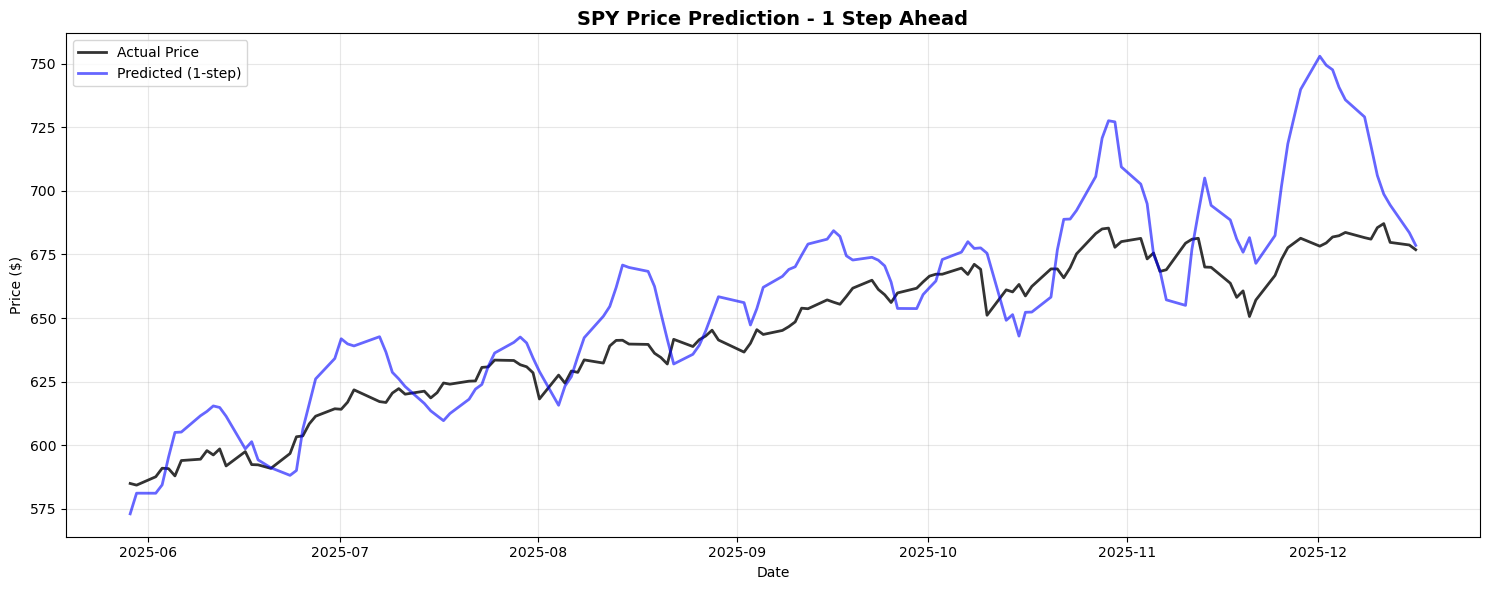

In [10]:
# Plot: Actual vs Predicted (1-step ahead)
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(predictions.index, predictions['actual_price'], 
        label='Actual Price', linewidth=2, color='black', alpha=0.8)
ax.plot(predictions.index, predictions['pred_price_1'], 
        label='Predicted (1-step)', linewidth=2, color='blue', alpha=0.6)

ax.set_title(f'{SYMBOL} Price Prediction - 1 Step Ahead', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5a. Directional Accuracy Analysis
**Trading-focused metric: Are we predicting UP/DOWN correctly?**

In [11]:
# Get detailed directional accuracy
print("Calculating directional accuracy (UP/DOWN prediction)...")
directional_metrics = predictor.get_directional_accuracy(predictions=predictions, detailed=True)

print("\nDirectional Accuracy by Prediction Step:")
print(directional_metrics.to_string())

# Highlight key metrics for 1-step prediction
print("\n" + "="*60)
print("KEY METRIC: 1-Step Directional Accuracy")
print("="*60)
step1 = directional_metrics.loc['step_1']
print(f"Overall Accuracy: {step1['Accuracy']:.2f}%")
print(f"Correct Predictions: {int(step1['Correct'])}/{int(step1['Total_Predictions'])}")
print(f"\nBreakdown:")
print(f"  Up Days Predicted Correctly: {int(step1['True_Up'])}/{int(step1['Actual_Up_Days'])} ({step1['Up_Accuracy']:.2f}%)")
print(f"  Down Days Predicted Correctly: {int(step1['True_Down'])}/{int(step1['Actual_Down_Days'])} ({step1['Down_Accuracy']:.2f}%)")
print(f"  False Signals: {int(step1['False_Up']) + int(step1['False_Down'])}")
print("="*60)

Calculating directional accuracy (UP/DOWN prediction)...

Directional Accuracy by Prediction Step:
          Accuracy  Total_Predictions  Correct  Incorrect  Actual_Up_Days  Actual_Down_Days  Actual_Flat_Days  True_Up  True_Down  False_Up  False_Down  Up_Accuracy  Down_Accuracy
step_1   48.201439              139.0     67.0       72.0            80.0              59.0               0.0     57.0       10.0      49.0        23.0        71.25      16.949153
step_2   50.359712              139.0     70.0       69.0            80.0              59.0               0.0     57.0       13.0      46.0        23.0        71.25      22.033898
step_3   53.237410              139.0     74.0       65.0            80.0              59.0               0.0     59.0       15.0      44.0        21.0        73.75      25.423729
step_4   49.640288              139.0     69.0       70.0            80.0              59.0               0.0     56.0       13.0      46.0        24.0        70.00      22.033898
s

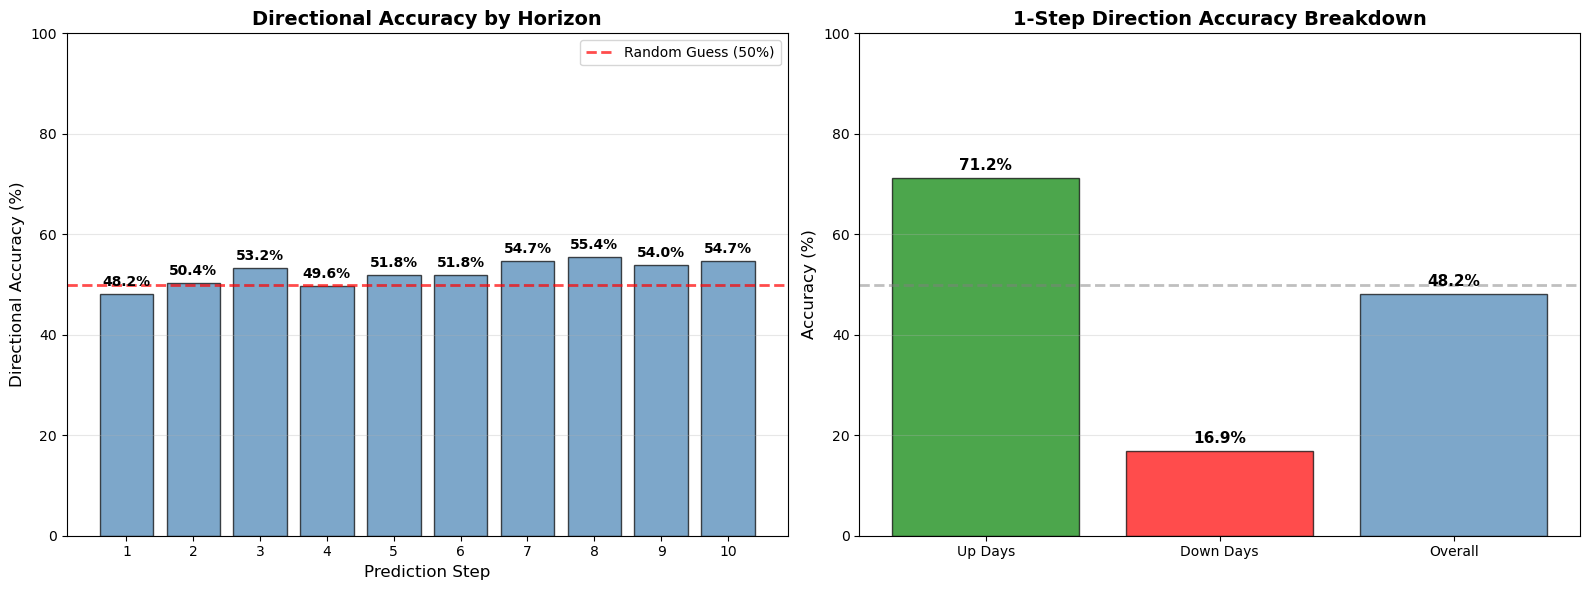

In [12]:
# Visualize directional accuracy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Accuracy by prediction step
ax1 = axes[0]
steps = [f'step_{i}' for i in range(1, min(11, len(directional_metrics) + 1))]
accuracies = [directional_metrics.loc[step, 'Accuracy'] if step in directional_metrics.index else 0 
              for step in steps]
step_labels = [str(i) for i in range(1, len(steps) + 1)]

bars = ax1.bar(step_labels, accuracies, alpha=0.7, edgecolor='black', color='steelblue')
ax1.axhline(y=50, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Random Guess (50%)')
ax1.set_xlabel('Prediction Step', fontsize=12)
ax1.set_ylabel('Directional Accuracy (%)', fontsize=12)
ax1.set_title('Directional Accuracy by Horizon', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, axis='y', alpha=0.3)
ax1.set_ylim([0, 100])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right: Up vs Down accuracy (1-step)
ax2 = axes[1]
if 'step_1' in directional_metrics.index:
    up_acc = directional_metrics.loc['step_1', 'Up_Accuracy']
    down_acc = directional_metrics.loc['step_1', 'Down_Accuracy']
    
    categories = ['Up Days', 'Down Days', 'Overall']
    values = [up_acc, down_acc, directional_metrics.loc['step_1', 'Accuracy']]
    colors = ['green', 'red', 'steelblue']
    
    bars = ax2.bar(categories, values, alpha=0.7, edgecolor='black', color=colors)
    ax2.axhline(y=50, color='gray', linestyle='--', linewidth=2, alpha=0.5)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.set_title('1-Step Direction Accuracy Breakdown', fontsize=14, fontweight='bold')
    ax2.set_ylim([0, 100])
    ax2.grid(True, axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 5b. Hit Rate Analysis (Tolerance-Based Accuracy)
**"Close enough" metric: How often are we within ±X% of actual price?**

In [13]:
# Calculate hit rates at multiple tolerance levels
print("Calculating hit rates (tolerance-based accuracy)...")
hit_rates = predictor.get_hit_rates(predictions=predictions, tolerance_levels=[0.001, 0.005, 0.01, 0.02, 0.05])

print("\nHit Rates by Tolerance Level:")
print(hit_rates.to_string())

# Highlight 1-step prediction
print("\n" + "="*60)
print("KEY METRIC: 1-Step Hit Rates")
print("="*60)
step1_hits = hit_rates.loc['step_1']
print(f"±0.1% tolerance: {step1_hits['±0.1%_HitRate']:.2f}% ({int(step1_hits['±0.1%_Hits'])} hits)")
print(f"±0.5% tolerance: {step1_hits['±0.5%_HitRate']:.2f}% ({int(step1_hits['±0.5%_Hits'])} hits)")
print(f"±1.0% tolerance: {step1_hits['±1.0%_HitRate']:.2f}% ({int(step1_hits['±1.0%_Hits'])} hits)")
print(f"±2.0% tolerance: {step1_hits['±2.0%_HitRate']:.2f}% ({int(step1_hits['±2.0%_Hits'])} hits)")
print(f"±5.0% tolerance: {step1_hits['±5.0%_HitRate']:.2f}% ({int(step1_hits['±5.0%_Hits'])} hits)")
print("="*60)

Calculating hit rates (tolerance-based accuracy)...

Hit Rates by Tolerance Level:
         ±0.1%_HitRate  ±0.1%_Hits  ±0.1%_Misses  ±0.5%_HitRate  ±0.5%_Hits  ±0.5%_Misses  ±1.0%_HitRate  ±1.0%_Hits  ±1.0%_Misses  ±2.0%_HitRate  ±2.0%_Hits  ±2.0%_Misses  ±5.0%_HitRate  ±5.0%_Hits  ±5.0%_Misses
step_1        2.857143         4.0         136.0      11.428571        16.0         124.0      24.285714        34.0         106.0      50.714286        71.0          69.0      90.714286       127.0          13.0
step_2        0.714286         1.0         139.0       6.428571         9.0         131.0      12.142857        17.0         123.0      22.857143        32.0         108.0      57.142857        80.0          60.0
step_3        2.142857         3.0         137.0       4.285714         6.0         134.0       8.571429        12.0         128.0      17.857143        25.0         115.0      42.142857        59.0          81.0
step_4        0.000000         0.0         140.0       2.857143  

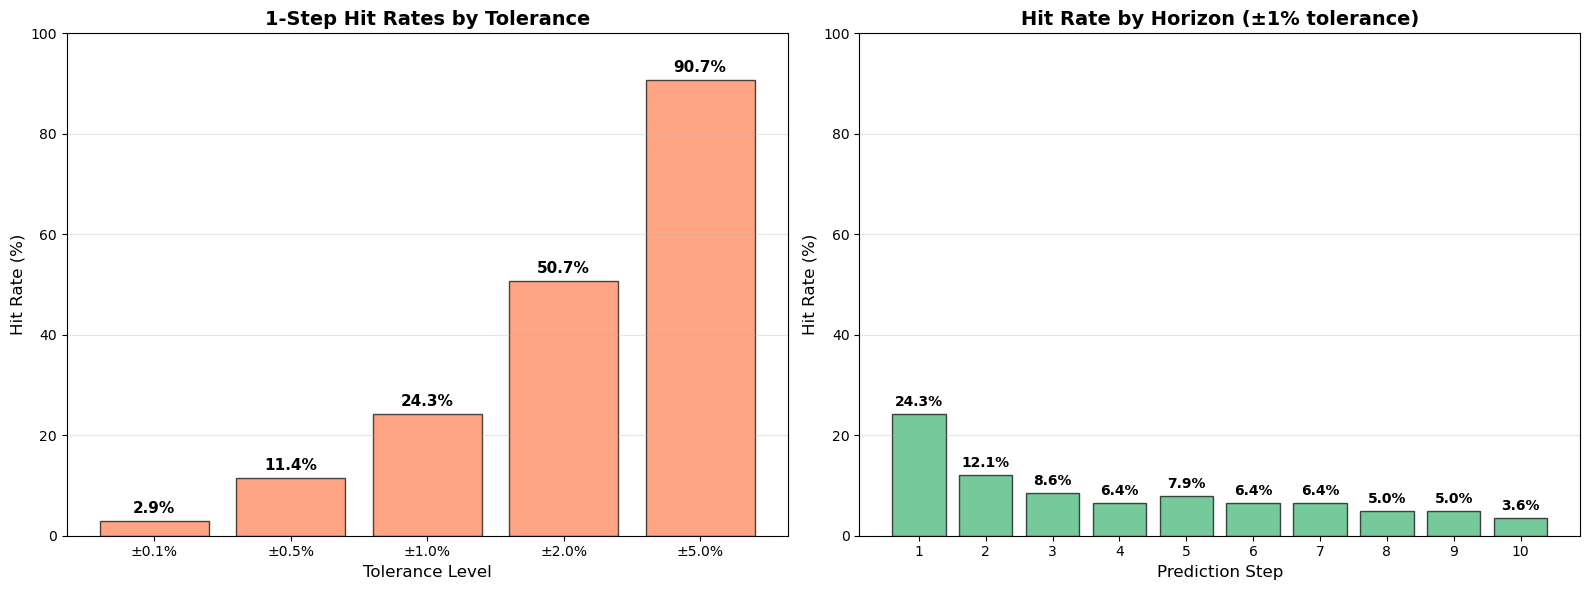

In [14]:
# Visualize hit rates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Hit rates by tolerance (1-step prediction)
ax1 = axes[0]
if 'step_1' in hit_rates.index:
    tolerances = ['±0.1%', '±0.5%', '±1.0%', '±2.0%', '±5.0%']
    hit_rate_values = [hit_rates.loc['step_1', f'{tol}_HitRate'] for tol in tolerances]
    
    bars = ax1.bar(tolerances, hit_rate_values, alpha=0.7, edgecolor='black', color='coral')
    ax1.set_xlabel('Tolerance Level', fontsize=12)
    ax1.set_ylabel('Hit Rate (%)', fontsize=12)
    ax1.set_title('1-Step Hit Rates by Tolerance', fontsize=14, fontweight='bold')
    ax1.set_ylim([0, 100])
    ax1.grid(True, axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, hit_rate_values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right: Hit rates across prediction steps (±1% tolerance)
ax2 = axes[1]
steps = [f'step_{i}' for i in range(1, min(11, len(hit_rates) + 1))]
if '±1.0%_HitRate' in hit_rates.columns:
    hit_rates_1pct = [hit_rates.loc[step, '±1.0%_HitRate'] if step in hit_rates.index else 0 
                      for step in steps]
    step_labels = [str(i) for i in range(1, len(steps) + 1)]
    
    bars = ax2.bar(step_labels, hit_rates_1pct, alpha=0.7, edgecolor='black', color='mediumseagreen')
    ax2.set_xlabel('Prediction Step', fontsize=12)
    ax2.set_ylabel('Hit Rate (%)', fontsize=12)
    ax2.set_title('Hit Rate by Horizon (±1% tolerance)', fontsize=14, fontweight='bold')
    ax2.set_ylim([0, 100])
    ax2.grid(True, axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, hit_rates_1pct):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Generating 140 predictions in batched mode...
Predictions complete!
Predictions complete!


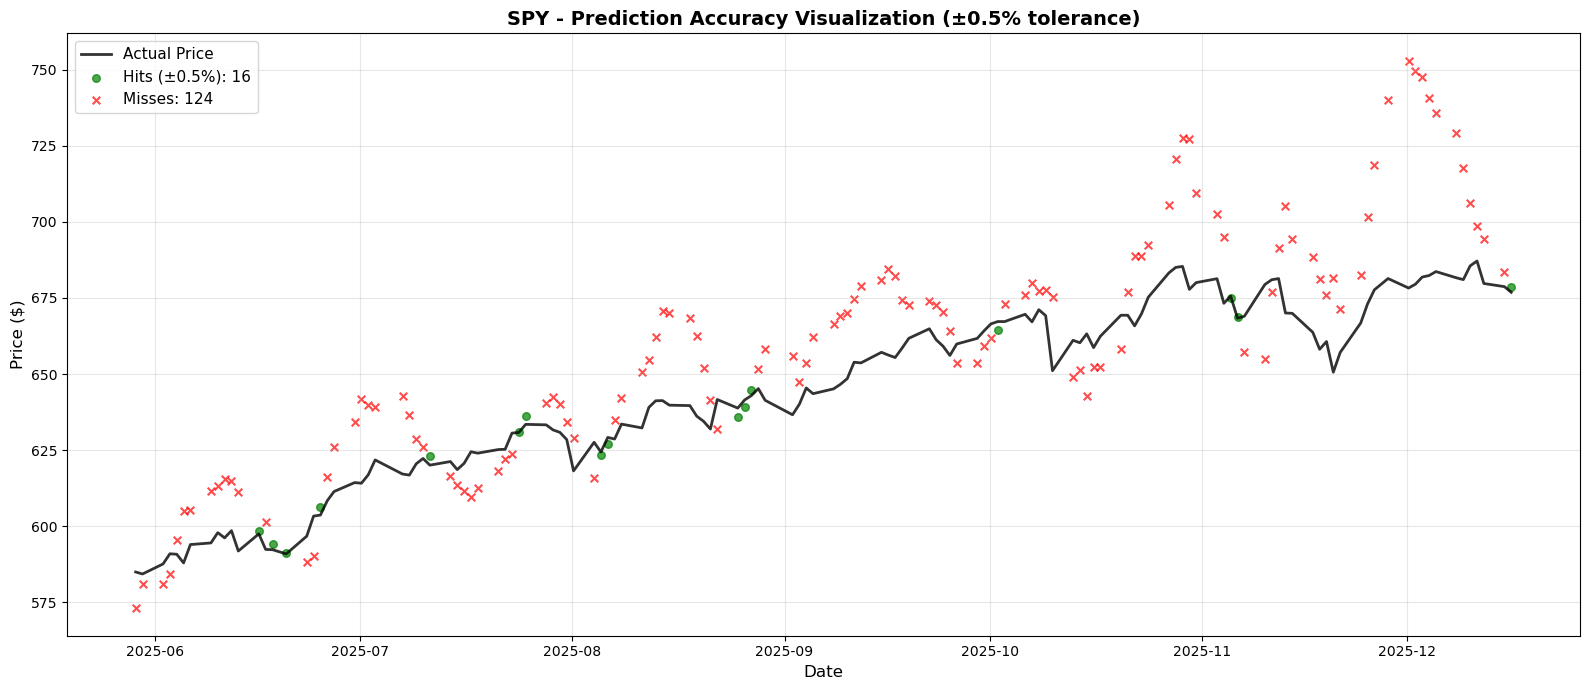


Overall Hit Rate (±0.5%): 11.43%
Hits: 16, Misses: 124


In [15]:
# Visualize prediction accuracy on actual price chart
fig, ax = plt.subplots(figsize=(16, 7))

# Get predictions for visualization
pred_df = predictor.predict(test_data)
actual = pred_df['actual_price'].values
pred_1step = pred_df['pred_price_1'].values

# Calculate which predictions are "hits" vs "misses" at ±0.5% tolerance
tolerance = 0.005
pct_error = np.abs((pred_1step - actual) / actual)
hits_mask = pct_error <= tolerance
misses_mask = ~hits_mask

# Plot actual price
ax.plot(pred_df.index, actual, label='Actual Price', linewidth=2, color='black', alpha=0.8)

# Scatter hits and misses on the price chart
ax.scatter(pred_df.index[hits_mask], pred_1step[hits_mask], 
          color='green', label=f'Hits (±0.5%): {np.sum(hits_mask)}', s=30, alpha=0.7, marker='o')
ax.scatter(pred_df.index[misses_mask], pred_1step[misses_mask], 
          color='red', label=f'Misses: {np.sum(misses_mask)}', s=30, alpha=0.7, marker='x')

ax.set_title(f'{SYMBOL} - Prediction Accuracy Visualization (±0.5% tolerance)', 
            fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price ($)', fontsize=12)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print hit rate summary
hit_rate = np.mean(hits_mask) * 100
print(f"\nOverall Hit Rate (±0.5%): {hit_rate:.2f}%")
print(f"Hits: {np.sum(hits_mask)}, Misses: {np.sum(misses_mask)}")

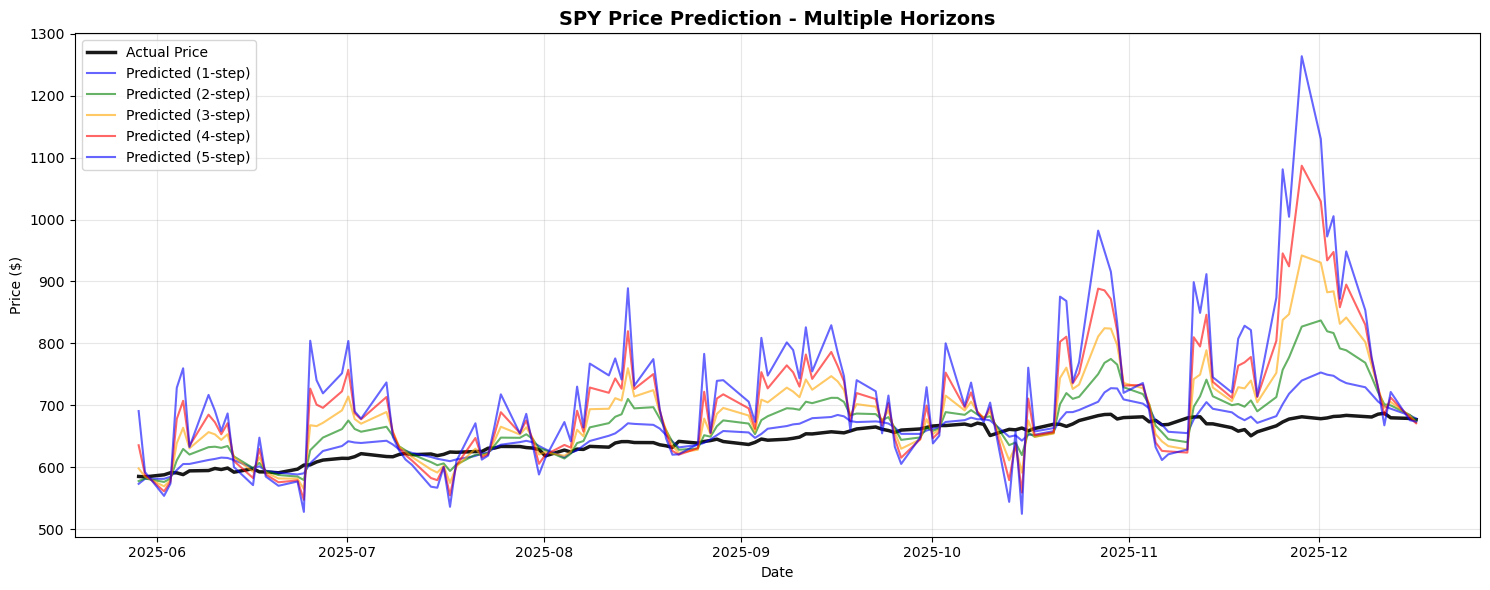

In [16]:
# Plot: Multiple prediction horizons
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(predictions.index, predictions['actual_price'], 
        label='Actual Price', linewidth=2.5, color='black', alpha=0.9)

# Plot different prediction steps with varying opacity
steps_to_plot = [1, 3, 5, 10] if PREDICTION_HORIZON >= 10 else list(range(1, PREDICTION_HORIZON + 1))
colors = ['blue', 'green', 'orange', 'red']

for i, step in enumerate(steps_to_plot):
    if step <= PREDICTION_HORIZON:
        ax.plot(predictions.index, predictions[f'pred_price_{step}'],
               label=f'Predicted ({step}-step)', linewidth=1.5, 
               color=colors[i % len(colors)], alpha=0.6)

ax.set_title(f'{SYMBOL} Price Prediction - Multiple Horizons', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

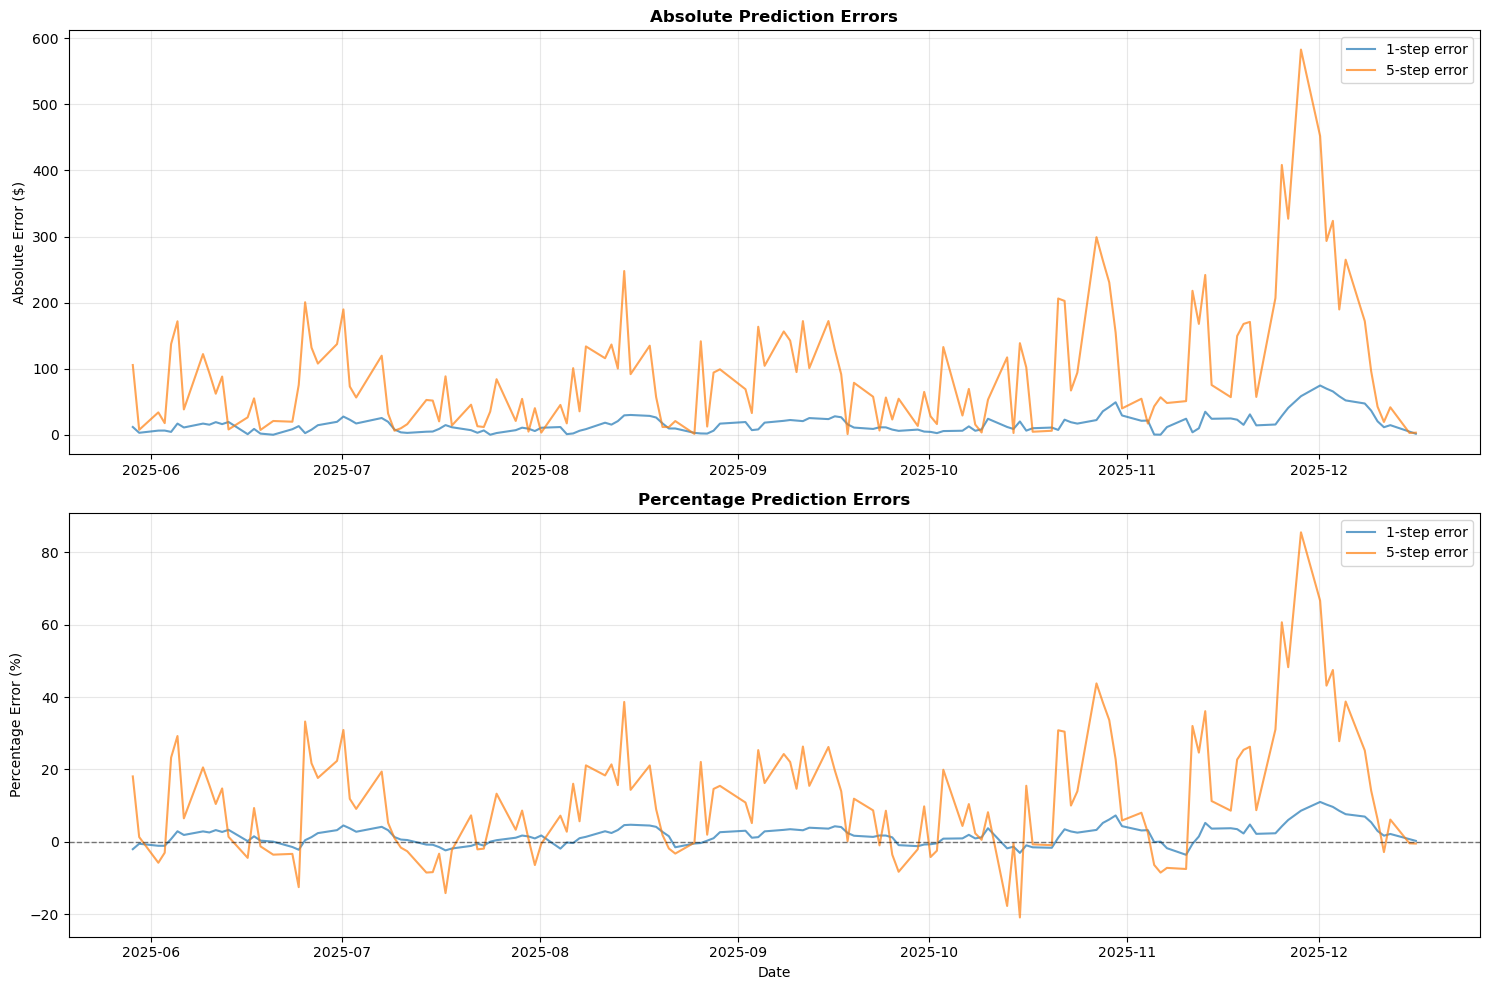

In [17]:
# Plot: Prediction errors over time
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Absolute errors
ax1 = axes[0]
for step in [1, 5, 10]:
    if step <= PREDICTION_HORIZON:
        errors = np.abs(predictions['actual_price'] - predictions[f'pred_price_{step}'])
        ax1.plot(predictions.index, errors, label=f'{step}-step error', alpha=0.7)

ax1.set_title('Absolute Prediction Errors', fontsize=12, fontweight='bold')
ax1.set_ylabel('Absolute Error ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Percentage errors
ax2 = axes[1]
for step in [1, 5, 10]:
    if step <= PREDICTION_HORIZON:
        pct_errors = (predictions[f'pred_price_{step}'] - predictions['actual_price']) / predictions['actual_price'] * 100
        ax2.plot(predictions.index, pct_errors, label=f'{step}-step error', alpha=0.7)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('Percentage Prediction Errors', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage Error (%)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Monthly Performance Analysis

In [18]:
# Analyze performance by month
predictions['year_month'] = predictions.index.to_period('M')

monthly_metrics = []

for period in predictions['year_month'].unique():
    month_data = predictions[predictions['year_month'] == period]
    
    if len(month_data) > 0:
        # Calculate metrics for 1-step prediction
        actual = month_data['actual_price'].values
        pred = month_data['pred_price_1'].values
        
        mae = np.mean(np.abs(actual - pred))
        rmse = np.sqrt(np.mean((actual - pred) ** 2))
        mape = np.mean(np.abs((actual - pred) / actual)) * 100
        
        monthly_metrics.append({
            'period': str(period),
            'n_days': len(month_data),
            'mae': mae,
            'rmse': rmse,
            'mape': mape
        })

monthly_df = pd.DataFrame(monthly_metrics)
print("\nMonthly Performance (1-step predictions):")
print(monthly_df.to_string(index=False))


Monthly Performance (1-step predictions):
 period  n_days       mae      rmse     mape
2025-05       2  7.557373  8.738904 1.292260
2025-06      20 10.627640 12.414799 1.776964
2025-07      22 10.309945 12.818280 1.659165
2025-08      21 13.226972 16.223631 2.076944
2025-09      21 15.707121 17.365830 2.407017
2025-10      23 16.773329 20.821825 2.493224
2025-11      19 21.352780 25.451242 3.183549
2025-12      12 38.203796 45.930544 5.607718


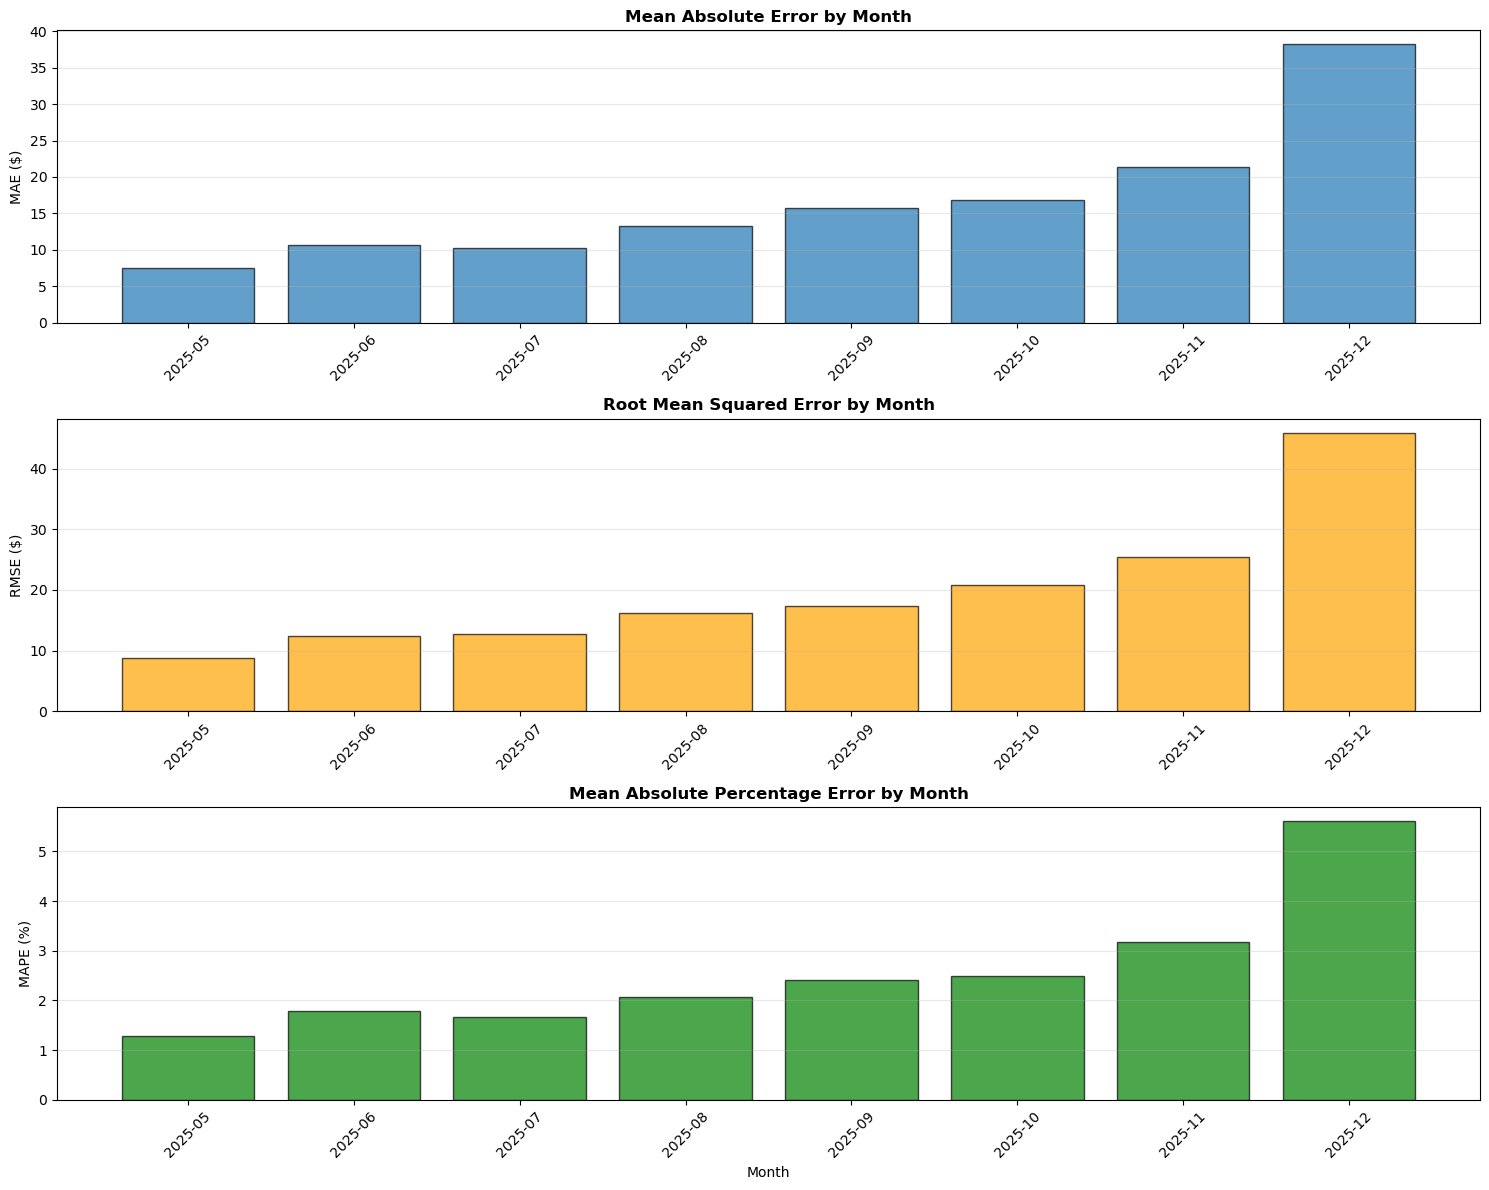

In [19]:
# Visualize monthly performance
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# MAE by month
ax1 = axes[0]
ax1.bar(range(len(monthly_df)), monthly_df['mae'], alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(monthly_df)))
ax1.set_xticklabels(monthly_df['period'], rotation=45)
ax1.set_title('Mean Absolute Error by Month', fontweight='bold')
ax1.set_ylabel('MAE ($)')
ax1.grid(True, axis='y', alpha=0.3)

# RMSE by month
ax2 = axes[1]
ax2.bar(range(len(monthly_df)), monthly_df['rmse'], alpha=0.7, edgecolor='black', color='orange')
ax2.set_xticks(range(len(monthly_df)))
ax2.set_xticklabels(monthly_df['period'], rotation=45)
ax2.set_title('Root Mean Squared Error by Month', fontweight='bold')
ax2.set_ylabel('RMSE ($)')
ax2.grid(True, axis='y', alpha=0.3)

# MAPE by month
ax3 = axes[2]
ax3.bar(range(len(monthly_df)), monthly_df['mape'], alpha=0.7, edgecolor='black', color='green')
ax3.set_xticks(range(len(monthly_df)))
ax3.set_xticklabels(monthly_df['period'], rotation=45)
ax3.set_title('Mean Absolute Percentage Error by Month', fontweight='bold')
ax3.set_ylabel('MAPE (%)')
ax3.set_xlabel('Month')
ax3.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Zoom into Specific Months

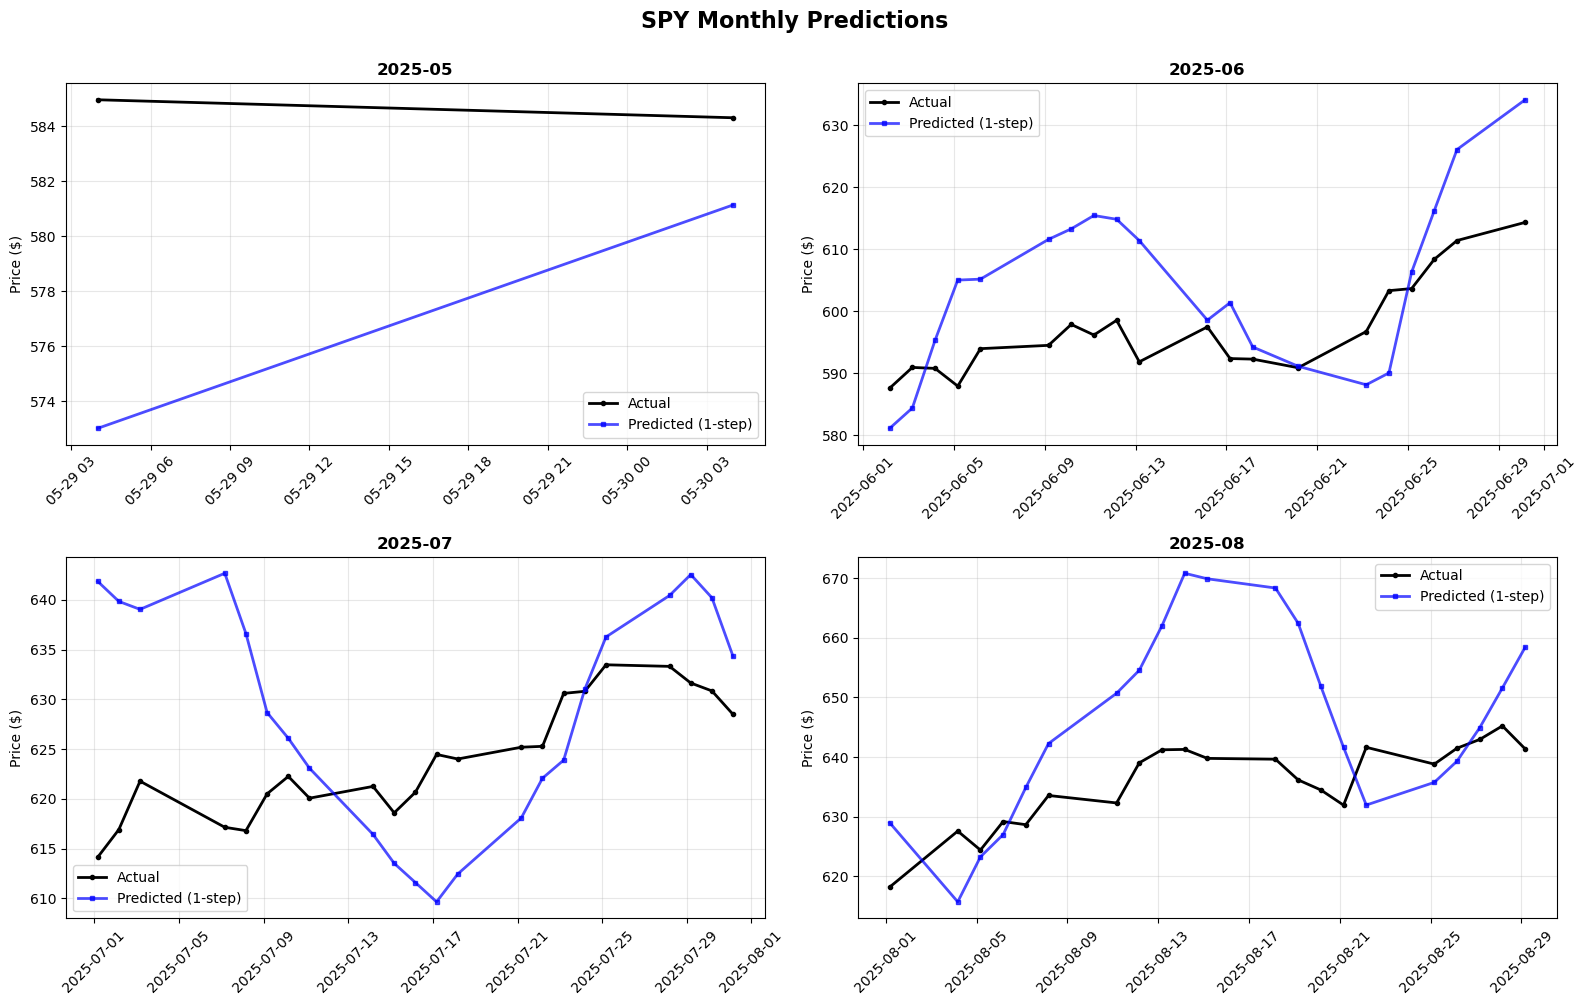

In [20]:
# Select a few months to visualize in detail
months_to_plot = predictions['year_month'].unique()[:4]  # First 4 months

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, period in enumerate(months_to_plot):
    if i >= len(axes):
        break
    
    month_data = predictions[predictions['year_month'] == period]
    
    ax = axes[i]
    ax.plot(month_data.index, month_data['actual_price'], 
           label='Actual', linewidth=2, color='black', marker='o', markersize=3)
    ax.plot(month_data.index, month_data['pred_price_1'], 
           label='Predicted (1-step)', linewidth=2, color='blue', marker='s', markersize=3, alpha=0.7)
    
    ax.set_title(f'{period}', fontweight='bold')
    ax.set_ylabel('Price ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'{SYMBOL} Monthly Predictions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [21]:
# Overall summary with trading metrics
print("="*60)
print("OVERALL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nSymbol: {SYMBOL}")
print(f"Training Period: {TRAIN_START} to {TRAIN_END}")
print(f"Testing Period: {TEST_START} to {TEST_END}")
print(f"\nModel Configuration:")
print(f"  Lookback Window: {LOOKBACK_WINDOW} candles")
print(f"  Prediction Horizon: {PREDICTION_HORIZON} candles")
print(f"  LSTM Units: {LSTM_UNITS}")
print(f"  Layers: {NUM_LAYERS}")
print(f"  Prediction Mode: {PREDICTION_MODE}")
print(f"\nTest Period Statistics:")
print(f"  Total trading days: {len(predictions)}")
print(f"  Months evaluated: {len(monthly_df)}")
print(f"\nAverage Monthly Performance (1-step):")
print(f"  MAE: ${monthly_df['mae'].mean():.2f}")
print(f"  RMSE: ${monthly_df['rmse'].mean():.2f}")
print(f"  MAPE: {monthly_df['mape'].mean():.2f}%")
print(f"\nBest Month: {monthly_df.loc[monthly_df['mae'].idxmin(), 'period']} (MAE: ${monthly_df['mae'].min():.2f})")
print(f"Worst Month: {monthly_df.loc[monthly_df['mae'].idxmax(), 'period']} (MAE: ${monthly_df['mae'].max():.2f})")

# Add trading-focused metrics
if 'step_1' in directional_metrics.index:
    print(f"\n{'='*60}")
    print("TRADING METRICS (1-Step Prediction)")
    print(f"{'='*60}")
    dir_acc = directional_metrics.loc['step_1', 'Accuracy']
    print(f"Directional Accuracy: {dir_acc:.2f}%")
    print(f"  → Predicts UP/DOWN correctly {dir_acc:.2f}% of the time")
    print(f"  → {'BETTER' if dir_acc > 50 else 'WORSE'} than random guess (50%)")
    
    if 'step_1' in hit_rates.index:
        hit_01 = hit_rates.loc['step_1', '±0.1%_HitRate']
        hit_05 = hit_rates.loc['step_1', '±0.5%_HitRate']
        hit_10 = hit_rates.loc['step_1', '±1.0%_HitRate']
        print(f"\nHit Rates (Tolerance-Based):")
        print(f"  ±0.1%: {hit_01:.2f}% of predictions")
        print(f"  ±0.5%: {hit_05:.2f}% of predictions")
        print(f"  ±1.0%: {hit_10:.2f}% of predictions")
        
print("="*60)

OVERALL PERFORMANCE SUMMARY

Symbol: SPY
Training Period: 2023-01-01 to 2024-12-31
Testing Period: 2025-01-01 to 2025-12-31

Model Configuration:
  Lookback Window: 100 candles
  Prediction Horizon: 5 candles
  LSTM Units: 50
  Layers: 2
  Prediction Mode: recursive

Test Period Statistics:
  Total trading days: 140
  Months evaluated: 8

Average Monthly Performance (1-step):
  MAE: $16.72
  RMSE: $19.97
  MAPE: 2.56%

Best Month: 2025-05 (MAE: $7.56)
Worst Month: 2025-12 (MAE: $38.20)

TRADING METRICS (1-Step Prediction)
Directional Accuracy: 48.20%
  → Predicts UP/DOWN correctly 48.20% of the time
  → WORSE than random guess (50%)

Hit Rates (Tolerance-Based):
  ±0.1%: 2.86% of predictions
  ±0.5%: 11.43% of predictions
  ±1.0%: 24.29% of predictions


## Next Steps & Experimentation Guide

**New Trading Metrics Available:**
- ✅ **Directional Accuracy**: Are we predicting UP/DOWN correctly?
- ✅ **Hit Rates with Tolerance**: "Close enough" accuracy at ±0.1%, ±0.5%, ±1%
- ✅ **Up/Down Breakdown**: Performance on bullish vs bearish days

**Compare with Your Friend's Approach:**
- Their method: 500-bar lookback, minute data, directional focus
- Your method: 100-bar lookback, daily data, multi-horizon forecasting
- **Now you can evaluate both on same metrics!**

**Experiment Ideas:**
1. **Match friend's setup**: Set `LOOKBACK_WINDOW = 500`, use minute data
2. **Test prediction modes**: Try `prediction_mode='direct'` vs `'recursive'`
3. **Optimize lookback**: Test 50, 100, 150, 200, 500 bars
4. **Different horizons**: Change `PREDICTION_HORIZON` (1, 5, 10, 20)
5. **More capacity**: Increase `LSTM_UNITS` (100, 150) or `NUM_LAYERS` (3, 4)
6. **Other symbols**: Test NVDA, AAPL, QQQ, etc.
7. **Intraday trading**: Switch to `TIMEFRAME_UNIT = "Minute"`, `MULTIPLIER = 5`